<a href="https://colab.research.google.com/github/pablobmm/analise_exploratoria_dados/blob/main/AP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Desafio 1**

In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Dados/AIDS_Classification.csv'
df = pd.read_csv(file_path)

df = df.dropna()
colunas = ['age', 'wtkg', 'cd40', 'cd420']
df[colunas] = df[colunas].apply(pd.to_numeric, errors='coerce')
df['cd4_delta'] = (df['cd420'] - df['cd40']).abs()

print("Check-up dos dados:")
print(df[colunas + ['cd4_delta']].info())
df.head()

Check-up dos dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        2139 non-null   int64  
 1   wtkg       2139 non-null   float64
 2   cd40       2139 non-null   int64  
 3   cd420      2139 non-null   int64  
 4   cd4_delta  2139 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 83.7 KB
None


,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected,cd4_delta
0,948,2,48,89.8128,0,0,0,100,0,0,...,1,0,1,0,422,477,566,324,0,55
1,1002,3,61,49.4424,0,0,0,90,0,1,...,3,0,1,0,162,218,392,564,1,56
2,961,3,45,88.4520,0,1,1,90,0,1,...,3,0,1,1,326,274,2063,1893,0,52
3,1166,3,47,85.2768,0,1,0,100,0,1,...,3,0,1,0,287,394,1590,966,0,107
4,1090,0,43,66.6792,0,1,0,100,0,1,...,3,0,0,0,504,353,870,782,0,151


A limpeza de dados é o alicerce pois garante que cálculos de médias e variações não sejam distorcidos por valores nulos ou erros de digitação. Um erro de tipo (como idade lida como texto) impediria cálculos matemáticos essenciais, podendo levar a diagnósticos errados sobre a progressão da doença.

**Desafio 2**

/tmp/ipykernel_336/3116149982.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='infected', y='wtkg', data=df, palette='Set2')
/tmp/ipykernel_336/3116149982.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='infected', y='age', data=df, palette='Pastel1')


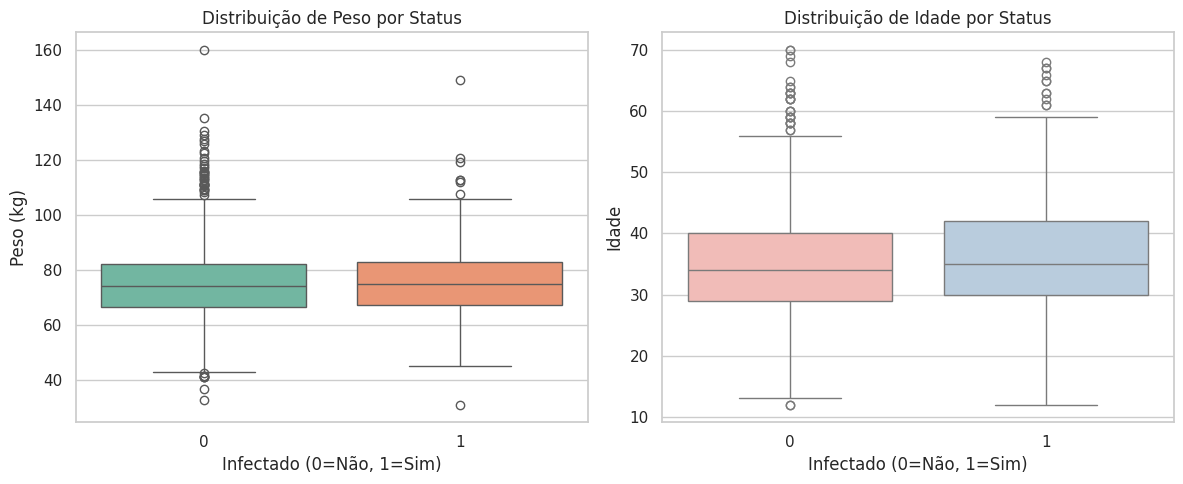

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='infected', y='wtkg', data=df, palette='Set2')
plt.title('Distribuição de Peso por Status')
plt.xlabel('Infectado (0=Não, 1=Sim)')
plt.ylabel('Peso (kg)')

plt.subplot(1, 2, 2)
sns.boxplot(x='infected', y='age', data=df, palette='Pastel1')
plt.title('Distribuição de Idade por Status')
plt.xlabel('Infectado (0=Não, 1=Sim)')
plt.ylabel('Idade')

plt.tight_layout()
plt.show()

Ao olhar os gráficos, se as caixas de um grupo e de outro estiverem quase na mesma altura, significa que idade e peso não fazem tanta diferença assim para definir se alguém está infectado ou não. Isso mostra que olhar só para esses dois fatores não basta para entender o quadro clínico do paciente.

**Desafio 3**

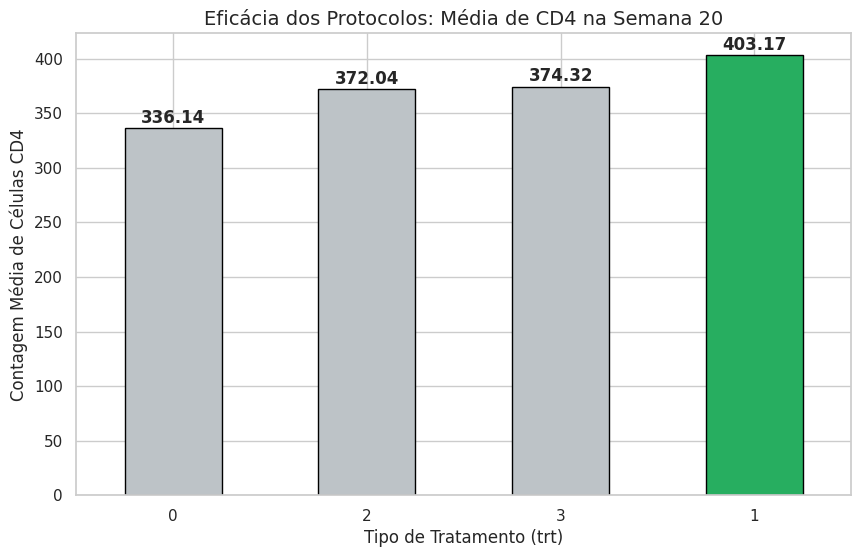

In [ ]:
medias_tratamento = df.groupby('trt')['cd420'].mean().sort_values()

melhor_trt = medias_tratamento.idxmax()
maior_valor = medias_tratamento.max()

cores = ['#bdc3c7' if val < maior_valor else '#27ae60' for val in medias_tratamento]

plt.figure(figsize=(10, 6))
grafico = medias_tratamento.plot(kind='bar', color=cores, edgecolor='black')

plt.title('Eficácia dos Protocolos: Média de CD4 na Semana 20', fontsize=14)
plt.xlabel('Tipo de Tratamento (trt)', fontsize=12)
plt.ylabel('Contagem Média de Células CD4', fontsize=12)
plt.xticks(rotation=0)

for i, v in enumerate(medias_tratamento):
    plt.text(i, v + 5, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

O tratamento 1 é o que realmente está mantendo a imunidade das pessoas na melhor condição, já o tratamento 0 deixa a desejar, deixando as pessoas mais expostas. Escolher o protocolo 1 é o investimento que faz mais sentido para o cuidado real com o paciente.

**Desafio 4**

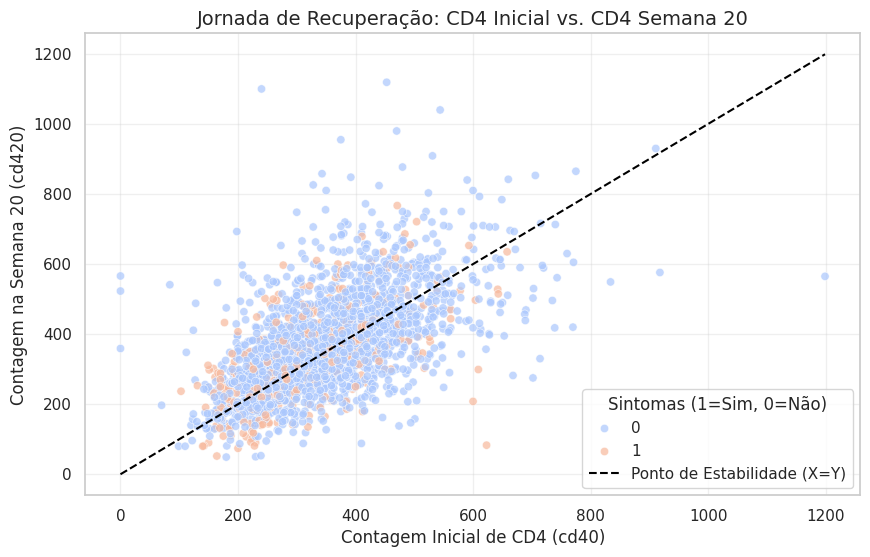

O índice de correlação entre cd40 e cd420 é: 0.58


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x='cd40', y='cd420', hue='symptom', data=df, palette='coolwarm', alpha=0.7)

plt.plot([df['cd40'].min(), df['cd40'].max()], [df['cd40'].min(), df['cd40'].max()],
         color='black', linestyle='--', label='Ponto de Estabilidade (X=Y)')

plt.title('Jornada de Recuperação: CD4 Inicial vs. CD4 Semana 20', fontsize=14)
plt.xlabel('Contagem Inicial de CD4 (cd40)', fontsize=12)
plt.ylabel('Contagem na Semana 20 (cd420)', fontsize=12)
plt.legend(title='Sintomas (1=Sim, 0=Não)')
plt.grid(True, alpha=0.3)

plt.show()

correlacao = df['cd40'].corr(df['cd420'])
print(f"O índice de correlação entre cd40 e cd420 é: {correlacao:.2f}")

O gráfico mostra que, embora quem começa melhor tende a terminar melhor.A recuperação do paciente médio mostra que mesmo aqueles que iniciam com o sistema imunológico mais fraco têm a chance de elevar seus níveis, indicando que o tratamento tem eficácia. Por outro lado, os a presença de sintomas muitas vezes puxa esses pontos para baixo, sugerindo que o sintoma é um peso extra que dificulta a subida, exigindo atenção redobrada da equipe médica.

**O Risco dos Sintomas Visíveis**

Probabilidade Geral de Infecção: 24.36%
Risco para pacientes COM sintomas: 36.49%
Risco para pacientes SEM sintomas: 21.82%


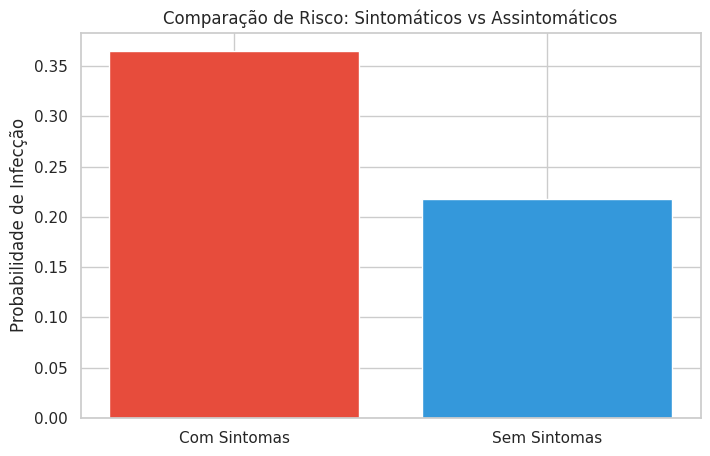

In [ ]:
p_infectado = df['infected'].mean()
p_condicional_sintoma = df[df['symptom'] == 1]['infected'].mean()
p_condicional_sem_sintoma = df[df['symptom'] == 0]['infected'].mean()

print(f"Probabilidade Geral de Infecção: {p_infectado:.2%}")
print(f"Risco para pacientes COM sintomas: {p_condicional_sintoma:.2%}")
print(f"Risco para pacientes SEM sintomas: {p_condicional_sem_sintoma:.2%}")

plt.figure(figsize=(8, 5))
plt.bar(['Com Sintomas', 'Sem Sintomas'],
        [p_condicional_sintoma, p_condicional_sem_sintoma],
        color=['#e74c3c', '#3498db'])
plt.ylabel('Probabilidade de Infecção')
plt.title('Comparação de Risco: Sintomáticos vs Assintomáticos')
plt.show()

Os dados revelam que a presença de sintomas atua como um indicador crítico, elevando  a probabilidade de infecção. No entanto, o hospital não deve considerar pacientes sem os sintomas como fora de perigo, pois a probabilidade para esse grupo ainda é estatisticamente relevante. A melhor estratégia  seria priorizar os testes caros para as pessoas com sintomas para a otimização de custos, mas manter protocolos de monitoramento para as pessoas sem sintomas, garantindo que casos silenciosos não passem despercebidos.